In [ ]:
# Data Cleaning & Understanding
# Objective:

# Understand dataset structure

# Questions:
# How many rows and columns are present?
# What are the data types of each feature?
# Are there null values?
# Are there duplicate records?
# Which columns need datatype conversion?
# How many unique customers, products, and categories exist?
# Which products generate the most transactions?


import pandas as pd 

df = pd.read_csv("data.csv.zip", encoding="latin1")
#rows and columns
print('1.',df.shape)
print('2.',df.columns)
print('3.',df.dtypes)
print('4.',df.isnull().sum())
print('5.',df.duplicated().sum())
print('6.',df.drop_duplicates())
print('7.', df.select_dtypes(include = 'object').columns)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('8.',df['InvoiceDate'])
print('9.' ,df['CustomerID'].nunique())
print('10.Products' , df['StockCode'].nunique())
print('11.Product Name ' , df['Description'].nunique())

most_transactions = (
    df.groupby(['StockCode' , 'Description'])['InvoiceNo']
    .count()
    .reset_index(name = 'Transaction_count')
    .sort_values(by = 'Transaction_count' , ascending = False)
)
print('Most Transaction : ' '\n',most_transactions.head())


1. (541909, 8)
2. Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
3. InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
4. InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
5. 5268
6.        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE

Mean of the amount: 17.98779487699964
Median of the amount: 9.75
Mode of the amount: 0    15.0
Name: Purchase_Amount, dtype: float64
Variance of sales :  143497.64000540902
Standard Deviation : 378.81082350615196
Range of customer spending :  336939.2
Highest Prices :
       StockCode      Description  Highest Price
4781          M           Manual       38970.00
4762  AMAZONFEE       AMAZON FEE       17836.46
4763          B  Adjust bad debt       11062.06
4783       POST          POSTAGE        8142.75
4780        DOT   DOTCOM POSTAGE        4505.17
...         ...              ...            ...
1677      22533            check           0.00
3615      84050          counted           0.00
4769   DCGS0003             ebay           0.00
1692      22548       adjustment           0.00
4772   DCGS0068             ebay           0.00

[4792 rows x 3 columns]
Lowest Price : 
      StockCode                          Description  Lowest Price
4763         B                      Adjust bad

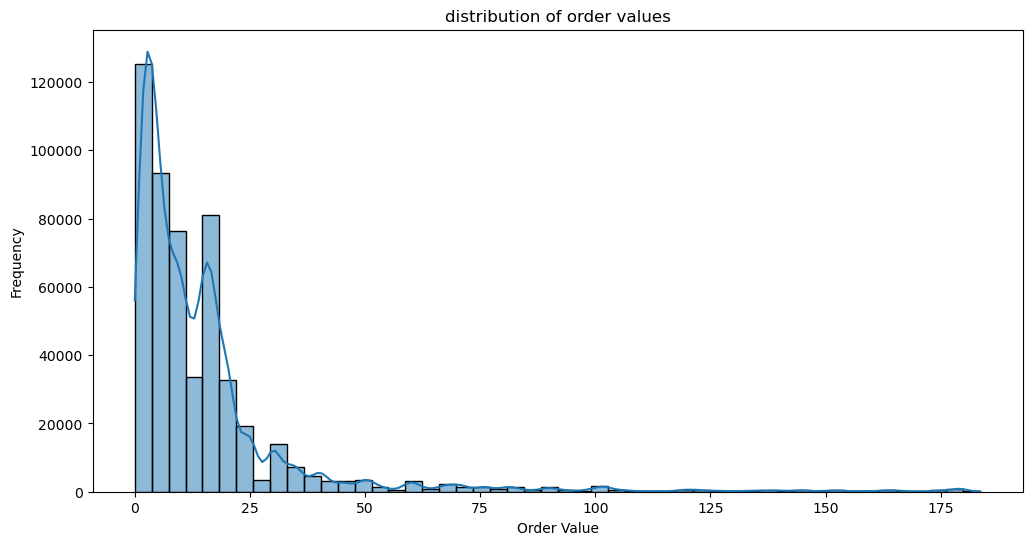

In [3]:
# Descriptive Statistics
# Objective:

# Use statistical foundations

# Questions:
# What is the mean, median, mode of purchase amount?
# What is the variance and standard deviation of sales?
# What is the range of customer spending?
# Which products have the highest and lowest prices?
# Are there outliers in purchase amount using Z-score?
# What does the distribution of order values look like?

from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

df.describe()
df['Purchase_Amount'] = df['UnitPrice'] * df['Quantity']
print('Mean of the amount:' , df['Purchase_Amount'].mean())
print('Median of the amount:' , df['Purchase_Amount'].median())
print('Mode of the amount:' , df['Purchase_Amount'].mode())

Sales = df['UnitPrice'] * df['Quantity']
print('Variance of sales : ' , Sales.var())
print('Standard Deviation :' , Sales.std())
Range = df['Purchase_Amount'].max() - df['Purchase_Amount'].min()
print('Range of customer spending : ' , Range)

Highest_Prices = (
    df.groupby(['StockCode' , 'Description'])['UnitPrice']
    .max()
    .reset_index(name = 'Highest Price')
    .sort_values(by = 'Highest Price' , ascending = False)
)
print('Highest Prices :' '\n', Highest_Prices )

Lowest_Price = (
    df.groupby(['StockCode' , 'Description'])['UnitPrice']
    .min()
    .reset_index(name = 'Lowest Price')
    .sort_values(by = 'Lowest Price' , ascending = True)
)
print("Lowest Price : " '\n' , Lowest_Price)

df['Z_score'] = zscore(df['Purchase_Amount'])
print('Z-Score : ' '\n', df['Z_score'])
Q1 = df['Purchase_Amount'].quantile(0.25)
Q3 = df['Purchase_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Purchase_Amount'] < lower_bound) | (df['Purchase_Amount'] > Upper_bound)]
print('Outliers :' '\n', outliers.head(4))


df['OrderValue'] = df['Quantity'] * df['UnitPrice']
clean_df = df[df['OrderValue']>0] #Keep only positive order values
upper_limit = clean_df['OrderValue'].quantile(0.99) # Optional — remove extreme outliers using 99th percentile
filter_df = clean_df[clean_df['OrderValue'] <= upper_limit]
plt.figure(figsize=(12,6))
sns.histplot(filter_df['OrderValue'] , bins = 50 , kde = True)
plt.title('distribution of order values')
plt.xlabel('Order Value')
plt.ylabel('Frequency')

plt.show()


Highest sales volume :  Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64
Most Orders :
 Country
United Kingdom    23494
Germany             603
France              461
EIRE                360
Belgium             119
Spain               105
Netherlands         101
Switzerland          74
Portugal             71
Australia            69
Name: InvoiceNo, dtype: int64
The Highest day / month is : 
 Month      Day      
December   Thursday     852
November   Wednesday    722
           Tuesday      716
           Thursday     624
October    Monday       588
          

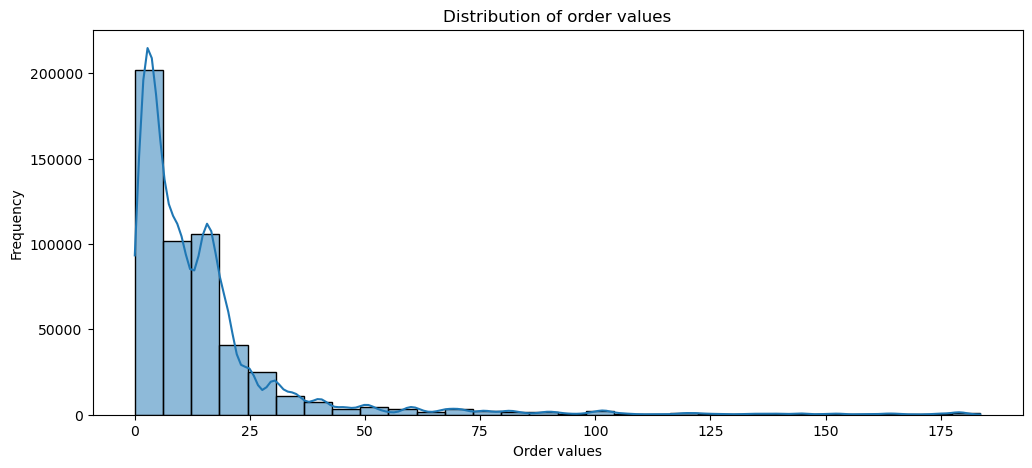

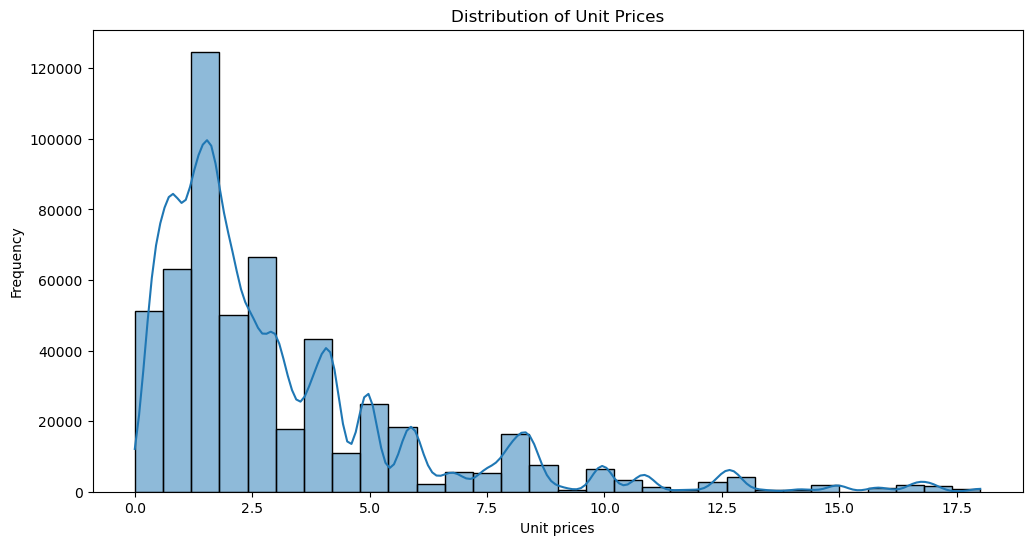

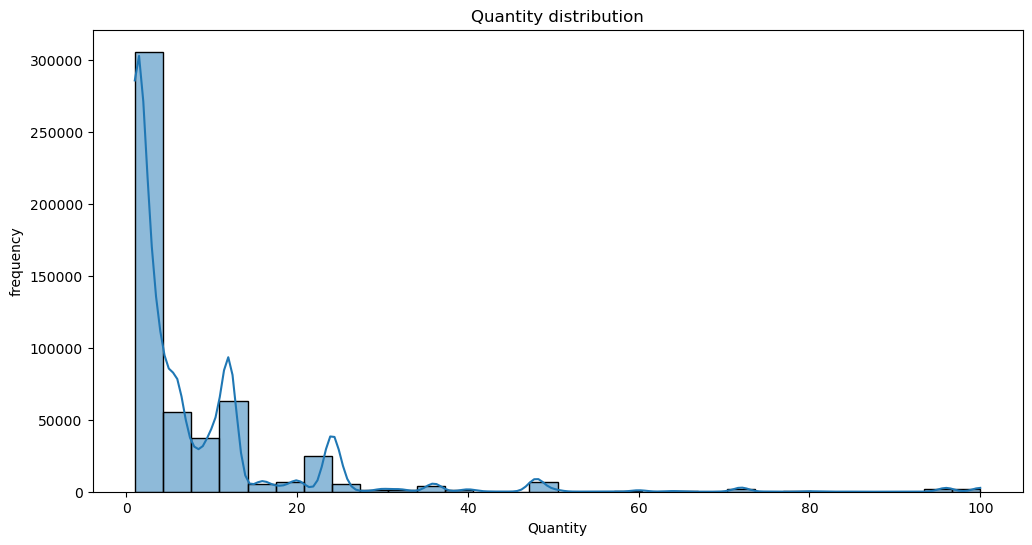

In [46]:
# Univariate Analysis
# Objective:

# Single-variable analysis

# Questions:
# Which category has highest sales volume?
# Which city/region has most orders? / # Which region spends the most?
# Which month/day has highest purchases?
# Which country generates highest revenue?
#Which products are sold most?
#Which customers spend the most?
#Analyze Distribution of Order Values
#Distribution of Unit Prices
#Distribution of Quantity Purchased

highest_sales_volume = (
    df.groupby(['Description'])['Quantity']
    .sum()
    .sort_values(ascending = False)
)

print('Highest sales volume : ' , highest_sales_volume.head(10))


most_orders = (
    df.groupby('Country')['InvoiceNo'].nunique()
    .sort_values(ascending = False)
)

print("Most Orders :""\n" , most_orders.head(10))

df['InvoiceDate'] =  pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month_name() #extracted month
df['Day'] = df['InvoiceDate'].dt.day_name() #extracted day 
highest_day_month = (
    df.groupby(['Month' , 'Day'])['InvoiceNo']
    .nunique()
    .sort_values(ascending = False)
    
)

print('The Highest day / month is : ' '\n' , highest_day_month.head(10))

df['Revenue'] = df['Quantity'] * df['UnitPrice']
country_generates = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending = False)
)

print('The revenue generated by the countries are :' '\n' , country_generates.head(10))

products_sold_most = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending = False)
)

print('The products which are sold the most:' '\n' , products_sold_most.head(10))

customers_spend_most = (
    df.groupby(['CustomerID'])['Revenue']
    .sum()
    .sort_values(ascending = False)
)

print('The customer who spent the most:' '\n', customers_spend_most.head(10))

df['OrderValue'] = df['UnitPrice'] * df['Quantity']

#to remove the extreme outliers , the negative values
clean_df = df[df['OrderValue'] > 0]
upper_limit = clean_df['OrderValue'].quantile(0.99)
filtered_df = clean_df[clean_df['OrderValue'] <= upper_limit] #set the limit
plt.figure(figsize=(12  , 5))
sns.histplot(filtered_df['OrderValue'] , kde = True , bins = 30)
plt.title('Distribution of order values')
plt.xlabel('Order values')
plt.ylabel('Frequency')
plt.show()

clean_df = df[df['UnitPrice'] > 0]
upper_limit = clean_df['UnitPrice'].quantile(0.99)
filtered_df = clean_df[clean_df['UnitPrice'] <= upper_limit]
plt.figure(figsize = (12,6))
sns.histplot(filtered_df['UnitPrice'] , kde = True , bins = 30)
plt.title("Distribution of Unit Prices")
plt.xlabel("Unit prices")
plt.ylabel('Frequency')
plt.show()


clean_df = df[df['Quantity'] > 0 ]
upper_limit = clean_df['Quantity'].quantile(0.99)
filtered_df = clean_df[clean_df['Quantity'] <= upper_limit]

plt.figure(figsize=(12,6))
sns.histplot(filtered_df['Quantity'] , bins = 30 , kde = True)
plt.title('Quantity distribution')
plt.xlabel('Quantity')
plt.ylabel('frequency')
plt.show()


In [ ]:
# Hypothesis Testing (Highly Valuable)
# T-Test:
# Do male vs female customers spend differently?
# Do premium customers spend more than regular customers?







